In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

In [2]:
import sys
import os
import h5py as h5
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(linewidth=180)
import opt_einsum
import scipy as sp
from scipy.linalg import eigh
from scipy.linalg import sqrtm
from scipy.linalg import inv
from numpy.linalg import cond

from os import path

import tqdm
from colorama import Fore

import gvar as gv
import lsqfit

import bs_utils

# Def parameters

In [3]:
p = dict()
p["debug"]   = False
p["verbose"] = False
p["latex"]   = True
p["save"] = True
p["fitter"] = 'scipy_least_squares'
p["fpath"] = {"nucleon": "./data/cosmon_c103_r005-8_nucleon.hdf5", 
                "nn": "./data/cosmon_c103_r005-8_deuteron_Swave.hdf5"}

In [4]:
p["t0"] = 5
p["td"] = 10
p['t_norm'] = 3
p['gevp']   = 'evp' # evp or gevp
p['get_Zj'] = True
p['Zjn_values'] = f"result/deuteron_Zjn_tNorm{p['t_norm']}_{p['gevp']}.h5"
p['show_Zjn']   = False
p['do_gevp']    = False #set to True if you want to do gevp if it was already done and saved

In [5]:
p["block"] = 2
#p['cfgs']  = [0,802[,1]] # use this to cut configs if desired 

p['svd_study'] = False
p['svdcut']    = 1e-8

p["bootstrap"] = False
p['Nbs_max']   = 5000
p['bs_seed']   = 'nn_c103_b%d' %p["block"]
p["nbs"]       = 5000
p["nbs_sub"]   = 100
p['bs0_width'] = 5
p['bs_prior']  = 'all' # 'gs' or 'all': 
                      # randomize prior mean for gs or all priors
#p['old_bs']    = True # set to True to use BS list from 2009.11825

p["autotime"]   = 10 # time used to estimate mean gs energy prior
p["sig_e0"]     = 1 # multiplication factor for meff[autotime] for prior width for deltaE_gs
p["sig_enn"]    = 1 # multiplication factor for meff[autotime] for prior width for deltaE_nn
p["positive_z"] = True

p["ratio"]       = False
p["ratio_type"]  = "data"
p["irreps"]      = "irreps_ben" #["irreps", "irreps_ben"]
p["version"]     = 'conspire'
p["gs_conspire"] = False # only add deltaE for ground state?
p["nstates"]     = 3
p["r_n_inel"]    = 2
p["r_n_el"]      = 0
p["trange"]      = {"N": [3, 20], "R": [3, 15]}

p["ampi"] = 0.310810
p["amn"]  = 0.70262
p["dE_elastic"] = 2 * np.sqrt(p["amn"]**2 + 1 * (2 * np.pi / 48) ** 2) -2*p["amn"]

# Define Channels

Comment out the long list and copy paste desired channel into the shorter dict to choose 1 specific channel. With the brackets around it. So p["masterkey"] = [ [ ( state ) ] ]. Weird thing with the fitting needs it to be a column vector, but the plotting needs it to be a row vector. If I make it into a row vector, things brek. 

In [6]:
# p["masterkey"] = [
#     [("0", "T1g", 0)], [('0', 'T1g', 1)],
#     [('1', 'A2', 0)], [('1', 'A2', 1)], 
#     [('1', 'E', 0)], [('1', 'E', 1)], [('4', 'E', 0)], [('4', 'E', 1)],
#     [('2', 'A2', 0)], [('4', 'A2', 0)], [('4', 'A2', 1)], 
#     [('2', 'B1', 0)], [('2', 'B2', 0)], [('2', 'B2', 3)],
#     [('3', 'A2', 0)], [('3', 'A2', 1)], [('3', 'E', 0)]
#     ]

p["masterkey"] = [ [('2', 'B2', 3)] ] 

In [7]:
print(p)

{'debug': False, 'verbose': False, 'latex': True, 'save': True, 'fitter': 'scipy_least_squares', 'fpath': {'nucleon': './data/cosmon_c103_r005-8_nucleon.hdf5', 'nn': './data/cosmon_c103_r005-8_deuteron_Swave.hdf5'}, 't0': 5, 'td': 10, 't_norm': 3, 'gevp': 'evp', 'get_Zj': True, 'Zjn_values': 'result/deuteron_Zjn_tNorm3_evp.h5', 'show_Zjn': False, 'do_gevp': False, 'block': 2, 'svd_study': False, 'svdcut': 1e-08, 'bootstrap': False, 'Nbs_max': 5000, 'bs_seed': 'nn_c103_b2', 'nbs': 5000, 'nbs_sub': 100, 'bs0_width': 5, 'bs_prior': 'all', 'autotime': 10, 'sig_e0': 1, 'sig_enn': 1, 'positive_z': True, 'ratio': False, 'ratio_type': 'data', 'irreps': 'irreps_ben', 'version': 'conspire', 'gs_conspire': False, 'nstates': 3, 'r_n_inel': 2, 'r_n_el': 0, 'trange': {'N': [3, 20], 'R': [3, 15]}, 'ampi': 0.31081, 'amn': 0.70262, 'dE_elastic': 0.024178894884214763, 'masterkey': [[('2', 'B2', 3)]]}


In [8]:
print(p["masterkey"][0])

[('2', 'B2', 3)]


# Fit NN

In [9]:
import nn_fit as fit
fit.main(p)
plt.close('all')

numpy: 1.26.4
opt_einsum: 3.4.0
scipy: 1.17.1
matplotlib: 3.10.8
h5py: 3.16.0
gvar: 13.1.7
lsqfit: 13.0.4
Read data from gvar dump
    ./data/gevp_deuteron_tnorm3_evp_5-10_block2.pickle


c:\P395\Deuteron GEVP Notebook\nn_fit.py:1374: RuntimeWarning: invalid value encountered in log
  y = np.log(data / np.roll(data, -1))[:-1]


getting NN reference states by Eff Mass


100%|██████████| 1/1 [00:05<00:00,  5.36s/it]


getting NN reference states by Z_jn overlaps

 ('2', 'B2')
op_j                                op_ID  level - max(Zjn)
   0    nucleon-F1(5) nucleon-F1(5): CG 0  20
   1    nucleon-F1(5) nucleon-F1(5): CG 1  17
   2    nucleon-F1(5) nucleon-F2(5): CG 0  16
   3    nucleon-F2(5) nucleon-F2(5): CG 0  19
   4    nucleon-F2(5) nucleon-F2(5): CG 1  17
   5     nucleon-G(3) nucleon-F1(5): CG 0  13
   6     nucleon-G(3) nucleon-F1(5): CG 1  12
   7     nucleon-G(3) nucleon-F2(5): CG 0  12
   8     nucleon-G(3) nucleon-F2(5): CG 1  13
   9      nucleon-G(2) nucleon-G(2): CG 0  5
  10      nucleon-G(2) nucleon-G(2): CG 1  7
  11      nucleon-G(2) nucleon-G(2): CG 3  7
  12     nucleon-G(2) nucleon-G1(4): CG 0  11
  13     nucleon-G(2) nucleon-G1(4): CG 1  11
  14    nucleon-G1(1) nucleon-F1(5): CG 0  9
  15    nucleon-G1(1) nucleon-F2(5): CG 0  8
  16     nucleon-G1(1) nucleon-G(3): CG 0  3
  17     nucleon-G1(1) nucleon-G(3): CG 1  5
  18    nucleon-G1(1) nucleon-G1(1): CG 0  2
  19    nucleon

c:\P395\Deuteron GEVP Notebook\nn_fit.py:259: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(lbl, figsize=(7,5.5))


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
bs fits: boot0


100%|██████████| 1/1 [00:00<00:00,  3.70it/s]

saving result


In [10]:
import plot_nn_stability_gevp as plotgevp

Namespace(optimal='result/NN_deuteron_tnorm3_t0-td_5-10_N_n3_t_3-20_NN_conspire_e0_t_3-15_ratio_False_block2.pickle', n_N=[3], nn_el=[0], ratio=False, gevp=['4-8', '4-10', '5-10', '5-12', '6-10', '6-12'], evp=True, tmin=range(2, 9), gs_cons=False, fig_type='pdf', test=False, debug=False)

loading optimal fit: result/NN_deuteron_tnorm3_t0-td_5-10_N_n3_t_3-20_NN_conspire_e0_t_3-15_ratio_False_block2.pickle
('2', 'B2', 3)
missing result/NN_deuteron_tnorm3_t0-td_4-8_N_n3_t_3-20_NN_conspire_e0_t_2-15_ratio_False_block2.pickle
missing result/NN_deuteron_tnorm3_t0-td_4-10_N_n3_t_3-20_NN_conspire_e0_t_2-15_ratio_False_block2.pickle
missing result/NN_deuteron_tnorm3_t0-td_5-10_N_n3_t_3-20_NN_conspire_e0_t_2-15_ratio_False_block2.pickle
missing result/NN_deuteron_tnorm3_t0-td_5-12_N_n3_t_3-20_NN_conspire_e0_t_2-15_ratio_False_block2.pickle
missing result/NN_deuteron_tnorm3_t0-td_6-10_N_n3_t_3-20_NN_conspire_e0_t_2-15_ratio_False_block2.pickle
missing result/NN_deuteron_tnorm3_t0-td_6-12_N_n3_t_3

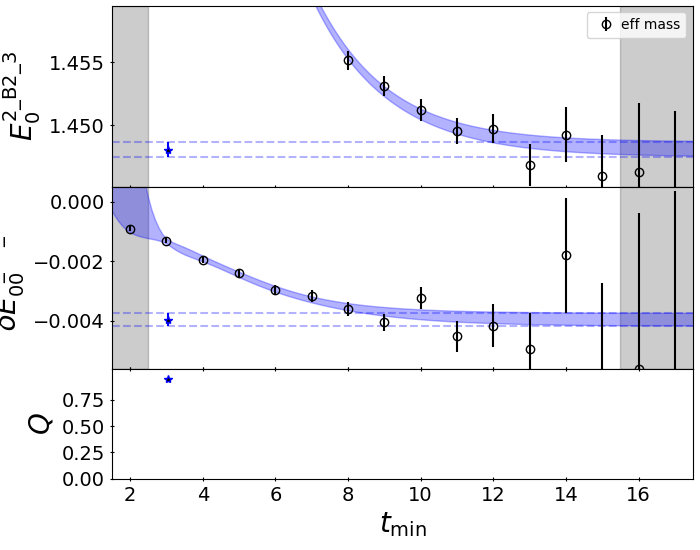

c:\P395\Deuteron GEVP Notebook\plot_nn_stability_gevp.py:139: SyntaxWarning: invalid escape sequence '\_'
  q_str = '\_'.join([str(k) for k in q])
c:\P395\Deuteron GEVP Notebook\plot_nn_stability_gevp.py:199: SyntaxWarning: invalid escape sequence '\_'
  fig_name = '%s_gevp_%s' %(q_str.replace('\_','_'), args.optimal.split('/')[-1].replace('pickle','stability.'+args.fig_type))
c:\P395\Deuteron GEVP Notebook\plot_nn_stability_gevp.py:226: SyntaxWarning: invalid escape sequence '\_'
  q_str = '\_'.join([str(k) for k in state])


KeyError: '0_T1g_0'

In [11]:
sys.argv = ["plot_nn_stability_gevp.py", "result/NN_deuteron_tnorm3_t0-td_5-10_N_n3_t_3-20_NN_conspire_e0_t_3-15_ratio_False_block2.pickle"]
plotgevp.main(p)

# This has not been fixed to work for arbitrary channels yet.

In [ ]:
import sys
sys.argv = ["print_params.py", "result/NN_deuteron_tnorm3_t0-td_5-10_N_n3_t_3-20_NN_conspire_e0_t_3-15_ratio_False_block2.pickle"]

!python print_params.py result/NN_deuteron_tnorm3_t0-td_5-10_N_n3_t_3-20_NN_conspire_e0_t_3-15_ratio_False_block2.pickle